# Project Part 5

## Candidate Dataset
I am using grade data my UI/UX desig class and my Data Science class. 
### The categories of the data are:
1. Name - Name of the assignment 
1. Category - The category or type of assignment
1. Due - The due date
1. Submitted - When it was submitted 
1. Score - Graded score 
1. OutOf - The pointsd the assignment was graded out of 
1. CleanCategory - Standardized category for assignemnts to help with data analysis

Scatter Plot time on x axis and then score percent score per assignemnt on the y axis

# Load and Clean data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsProjectData import clean_category
df = pd.read_csv('projectData.csv')

df["CleanCategory"] = df.apply(clean_category, axis=1)

df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["OutOf"] = pd.to_numeric(df["OutOf"], errors="coerce")
df["Percent"] = (df["Score"] / df["OutOf"]) * 100


df.to_csv("cleaned_grades.csv", index=False)

plt.style.use('seaborn-v0_8-whitegrid')

## Cleaning Notes
This file was already pretty close to being clean:
- I used chatGPT to format copy and pasted data from canvas into a csv
    - I then cleaned this file to make the data more usable
- The assignment category was standardized into quizes, exams/tests, small assignemnts, and big assignments
- The rest of the categories were fine as is



## Boxplot
Boxplot of grade distribution by assignment Category

<Figure size 640x480 with 0 Axes>

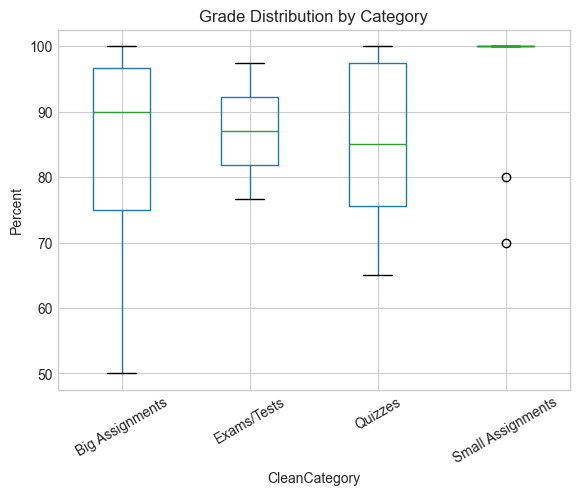

In [3]:
plt.figure()
graded = df.dropna(subset=["Score", "OutOf"])
graded.boxplot(column="Percent", by="CleanCategory")

plt.ylabel("Percent")
plt.title("Grade Distribution by Category")
plt.suptitle("")
plt.xticks(rotation=30)
plt.show()

# Bar Chart
Bar chart showing showing average percent per category 

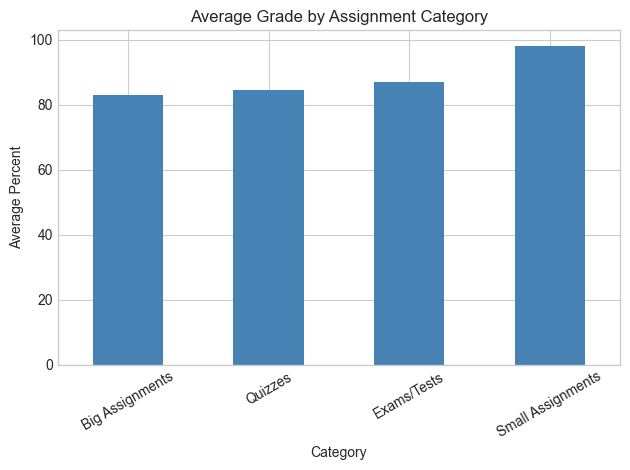

In [4]:

avg_by_cat = graded.groupby("CleanCategory")["Percent"].mean().sort_values()

plt.figure()
avg_by_cat.plot(kind="bar", color="steelblue")
plt.title("Average Grade by Assignment Category")
plt.ylabel("Average Percent")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Hypothesis Test
Testing whether average grade is above 80%

In [5]:
from scipy import stats

## Hypothesis Test: Is my average grade significantly above 80%?
# H0: mean percent <= 80
# H1: mean percent > 80

sample = graded["Percent"].dropna()
t_stat, p_value = stats.ttest_1samp(sample, popmean=80, alternative="greater")

print(f"Sample mean: {sample.mean():.2f}%")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Evidence that mean grade is significantly above 80%")
else:
    print("Fail to reject H0")

Sample mean: 91.09%
t-statistic: 5.8815
p-value: 0.0000
Reject H0: Evidence that mean grade is significantly above 80%
